Обучение модели...
Epoch [1/10], Loss: 63944.5911
Epoch [2/10], Loss: 31480.7747
Epoch [3/10], Loss: 28242.1471
Epoch [4/10], Loss: 23164.3301
Epoch [5/10], Loss: 21364.2591
Epoch [6/10], Loss: 14851.5622
Epoch [7/10], Loss: 12732.5645
Epoch [8/10], Loss: 6848.9772
Epoch [9/10], Loss: 5861.9719
Epoch [10/10], Loss: 5826.3690
Проверка модели на практике...
Выровненное изображение сохранено как peper/aligned_images/2aligned_test_image.png.


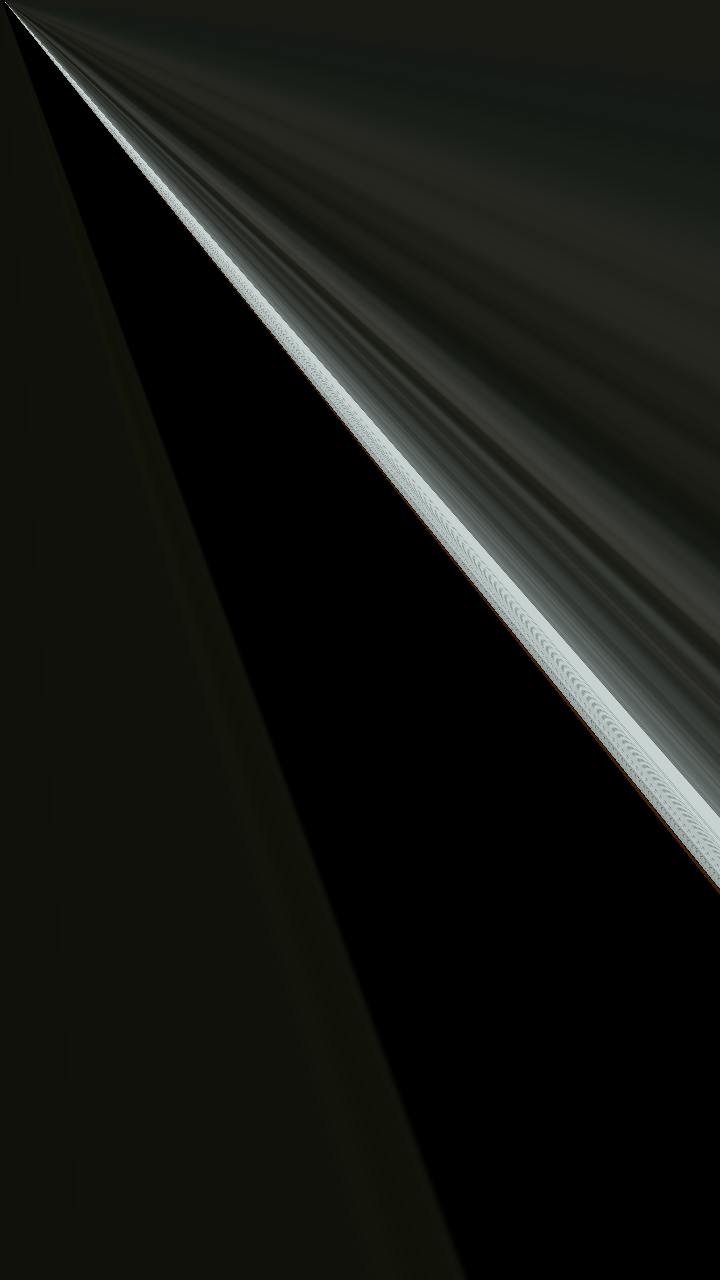

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import cv2
import numpy as np
import os
from IPython.display import Image, display

# Класс для загрузки данных
class HomographyDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path = self.data.iloc[idx, 0]
        image = cv2.imread(image_path)
        if image is None:
            print(f"Ошибка: Не удалось загрузить изображение {image_path}.")
            return None
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Преобразуем в RGB
        if self.transform:
            image = self.transform(image)

        # Параметры гомографии
        homography_params = self.data.iloc[idx, 1:].values.astype(np.float32)
        homography_params = torch.tensor(homography_params, dtype=torch.float32)

        return image, homography_params

# Архитектура нейронной сети
class HomographyNet(nn.Module):
    def __init__(self):
        super(HomographyNet, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 32 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 8),  # 8 параметров гомографии
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)  # Разворачиваем в вектор
        x = self.fc(x)
        return x

# Функция для обучения модели
def train_model(csv_file, num_epochs=10):
    # Преобразования для изображений
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),  # Изменяем размер изображения
        transforms.ToTensor(),  # Преобразуем в тензор
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Нормализация
    ])

    # Загрузка данных
    dataset = HomographyDataset(csv_file=csv_file, transform=transform)
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Создаем модель
    model = HomographyNet()
    criterion = nn.MSELoss()  # Среднеквадратичная ошибка
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Обучение
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            # Обнуляем градиенты
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass и оптимизация
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    return model

# Функция для проверки модели на практике
def test_model(image_path, model, output_path):
    # Преобразования для изображения
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),  # Изменяем размер изображения
        transforms.ToTensor(),  # Преобразуем в тензор
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Нормализация
    ])

    # Загружаем и предобрабатываем изображение
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: Не удалось загрузить изображение {image_path}.")
        return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tensor = transform(image_rgb).unsqueeze(0)  # Добавляем batch dimension

    # Предсказываем параметры гомографии
    with torch.no_grad():
        predicted_params = model(image_tensor)

    # Преобразуем параметры в матрицу гомографии
    predicted_params = predicted_params.numpy().flatten()  # Преобразуем в массив из 8 элементов
    M = np.append(predicted_params, 1.0).reshape(3, 3)  # Добавляем 1 и преобразуем в матрицу 3x3

    # Выравниваем изображение
    height, width = image.shape[:2]
    aligned_image = cv2.warpPerspective(image, M, (width, height))

    # Сохраняем результат
    cv2.imwrite(output_path, aligned_image)
    print(f"Выровненное изображение сохранено как {output_path}.")

    # Показываем результат в Jupyter Notebook
    display(Image(filename=output_path))

# Основной код
if __name__ == "__main__":
    # Пути к файлам
    csv_file = "homography_data.csv"  # CSV-файл с данными
    test_image_path = "peper/input_images/1frame_0161.jpg"  # Путь к тестовому изображению
    output_image_path = "peper/aligned_images/2aligned_test_image.png"  # Путь для сохранения результата

    # Обучаем модель
    print("Обучение модели...")
    model = train_model(csv_file, num_epochs=10)

    # Проверяем модель на практике
    print("Проверка модели на практике...")
    test_model(test_image_path, model, output_image_path)